# 🔷 Tipos de Grafos

**Conteúdo:** Grafo simples, dirigido, completo, ciclo e roda.

---

In [1]:
# Importando bibliotecas
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
%matplotlib inline

## 1. Grafo Simples

### 📚 Definição:

Um **grafo simples** é um grafo que:
- **Não possui laços** (sem self-loops)
- **Não possui arestas paralelas** (no máximo uma aresta entre cada par de vértices)

### Notação:
Num grafo simples, uma aresta com vértices (nós terminais) $u$ e $v$ é representada por $uv$.

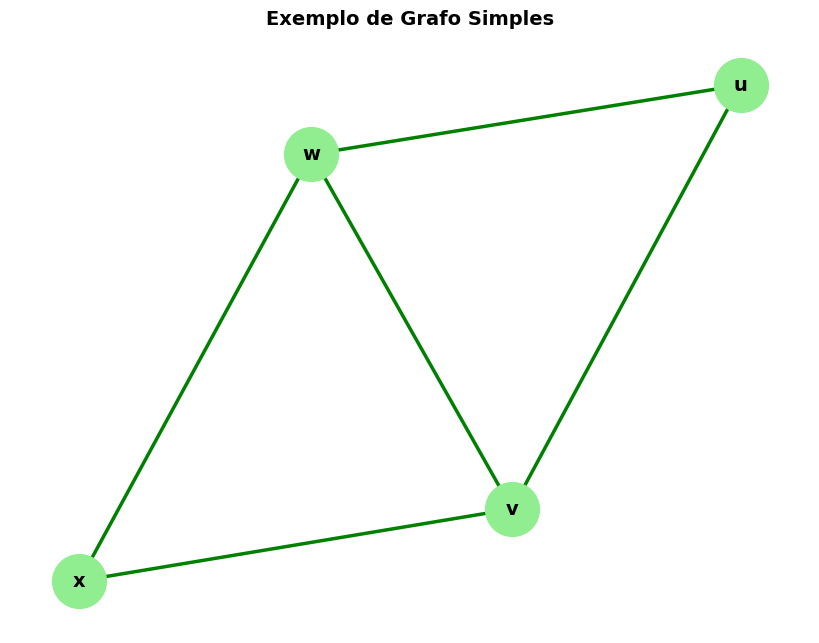

Características do Grafo Simples:
✓ Sem laços
✓ Sem arestas paralelas

Vértices: ['u', 'v', 'w', 'x']
Arestas: [('u', 'v'), ('u', 'w'), ('v', 'w'), ('v', 'x'), ('w', 'x')]


In [2]:
# Criando um grafo simples
G_simples = nx.Graph()
G_simples.add_edges_from([('u', 'v'), ('u', 'w'), ('v', 'w'), ('v', 'x'), ('w', 'x')])

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True, constrained_layout=True)
pos = nx.spring_layout(G_simples, seed=42)
nx.draw(G_simples, pos,
        with_labels=True,
        node_color='lightgreen',
        node_size=1500,
        font_size=14,
        font_weight='bold',
        edge_color='green',
        width=2.5, ax=ax)
ax.set_title('Exemplo de Grafo Simples', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

print("Características do Grafo Simples:")
print(f"✓ Sem laços")
print(f"✓ Sem arestas paralelas")
print(f"\nVértices: {list(G_simples.nodes())}")
print(f"Arestas: {list(G_simples.edges())}")

### 📝 Exemplo dos Slides:

**Pergunta:** Quais são os grafos com quatro vértices $\{u, v, w, x\}$ e duas arestas, sendo que uma delas é a aresta $uv$?

**Solução:** Dado quatro vértices, existem $\binom{4}{2} = 6$ subconjuntos de 2 vértices:
$$\{uv, uw, ux, vw, vx, wx\}$$

Como uma aresta já é $uv$, as 5 possibilidades para a segunda aresta são: $\{uw, ux, vw, vx, wx\}$

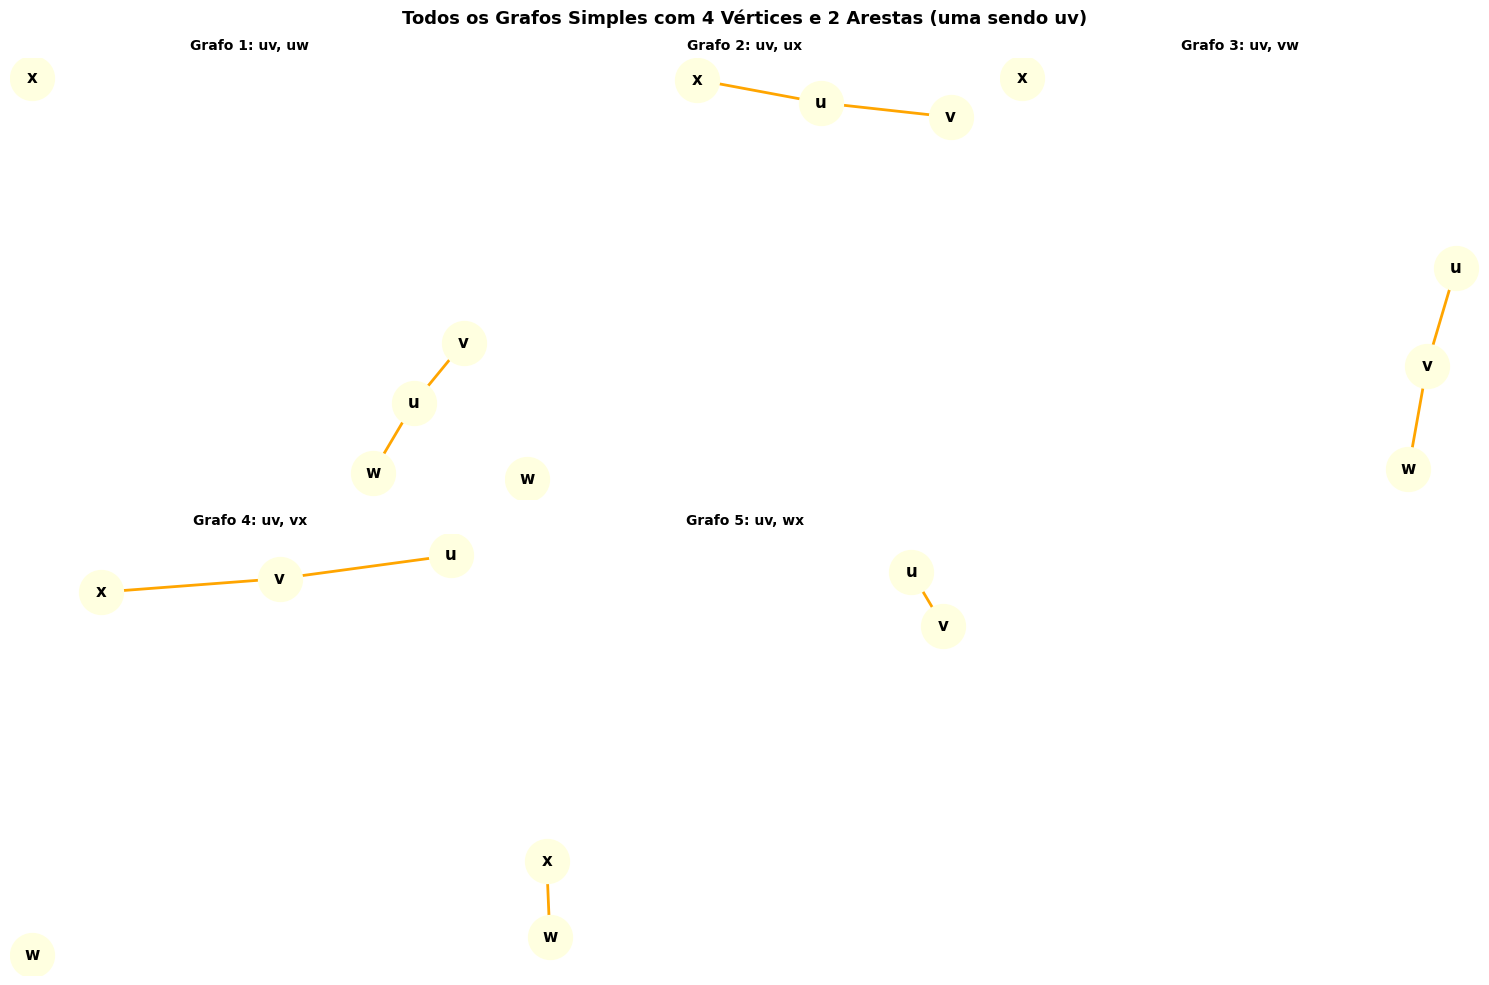

Total de possibilidades: 5


In [3]:
# Todos os grafos simples com 4 vértices e 2 arestas (uma sendo uv)
fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
axes = axes.flatten()

vertices = ['u', 'v', 'w', 'x']
segunda_aresta_opcoes = [('u', 'w'), ('u', 'x'), ('v', 'w'), ('v', 'x'), ('w', 'x')]

for i, segunda_aresta in enumerate(segunda_aresta_opcoes):
    G = nx.Graph()
    G.add_nodes_from(vertices)
    G.add_edges_from([('u', 'v'), segunda_aresta])
    
    pos = nx.spring_layout(G, seed=42)
    nx.draw(G, pos, ax=axes[i],
            with_labels=True,
            node_color='lightyellow',
            node_size=1000,
            font_size=12,
            font_weight='bold',
            edge_color='orange',
            width=2)
    axes[i].set_title(f'Grafo {i+1}: uv, {segunda_aresta[0]}{segunda_aresta[1]}', 
                     fontsize=10, fontweight='bold')
    axes[i].axis('off')

# Remover o último subplot (não usado)
fig.delaxes(axes[5])

plt.suptitle('Todos os Grafos Simples com 4 Vértices e 2 Arestas (uma sendo uv)', 
             fontsize=13, fontweight='bold', y=0.98)
plt.show()

print(f"Total de possibilidades: {len(segunda_aresta_opcoes)}")

---

## 2. Grafo Dirigido (Digrafo)

### 📚 Definição:

Um **grafo dirigido** (ou **digrafo** ou **direcionado**) $G$ consiste de:
1. Vértices $V(G)$
2. **Arestas dirigidas** $E(G)$, onde cada aresta é associada a um **par ordenado** de vértices

Se a aresta $e$ é associada ao par $(u, v)$, dizemos que $e$ é a **aresta dirigida de** $u$ **para** $v$.

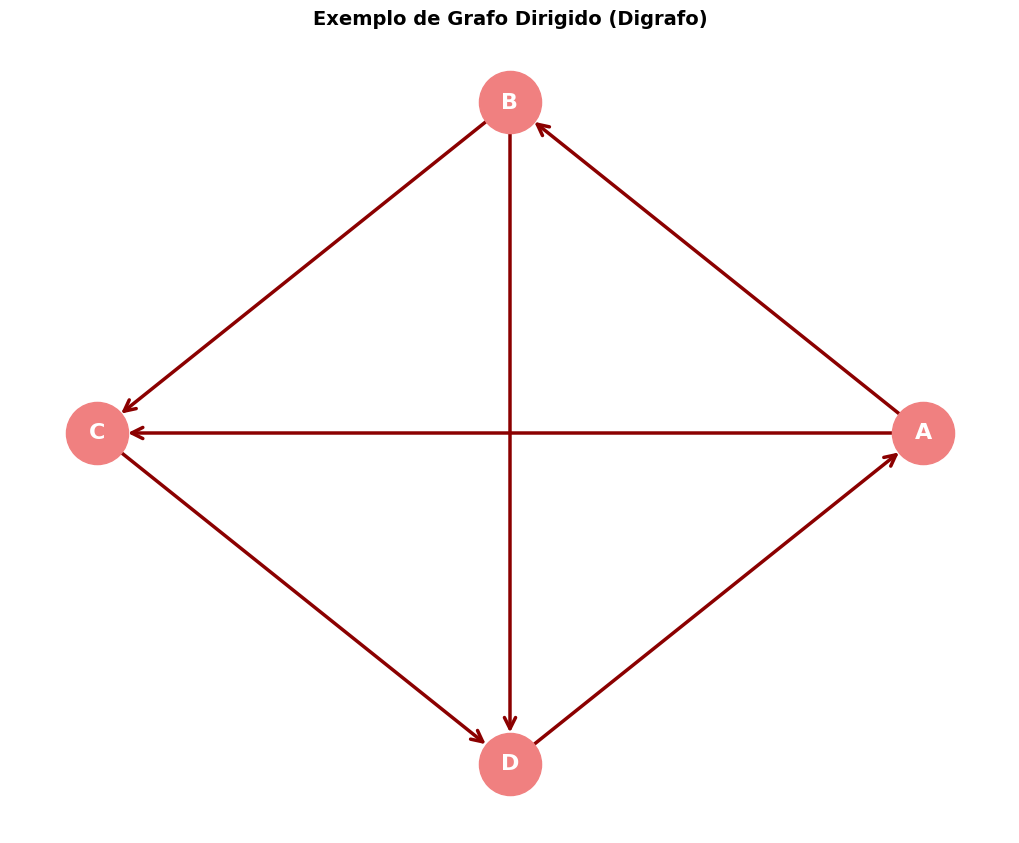

Características do Grafo Dirigido:
✓ Arestas têm direção (setas)
✓ (u,v) ≠ (v,u)

Arestas dirigidas: [('A', 'B'), ('A', 'C'), ('B', 'C'), ('B', 'D'), ('C', 'D'), ('D', 'A')]


In [4]:
# Criando um grafo dirigido
G_dirigido = nx.DiGraph()
G_dirigido.add_edges_from([
    ('A', 'B'), ('B', 'C'), ('C', 'D'), 
    ('D', 'A'), ('A', 'C'), ('B', 'D')
])

fig, ax = plt.subplots(figsize=(10, 8), constrained_layout=True, constrained_layout=True)
pos = nx.circular_layout(G_dirigido)
nx.draw(G_dirigido, pos,
        with_labels=True,
        node_color='lightcoral',
        node_size=2000,
        font_size=16,
        font_weight='bold',
        font_color='white',
        edge_color='darkred',
        width=2.5,
        arrows=True,
        arrowsize=20,
        arrowstyle='->', ax=ax)
ax.set_title('Exemplo de Grafo Dirigido (Digrafo)', fontsize=14, fontweight='bold')
plt.axis('off')
plt.show()

print("Características do Grafo Dirigido:")
print(f"✓ Arestas têm direção (setas)")
print(f"✓ (u,v) ≠ (v,u)")
print(f"\nArestas dirigidas: {list(G_dirigido.edges())}")

### Conversão: Grafo Dirigido ↔ Grafo Não Dirigido

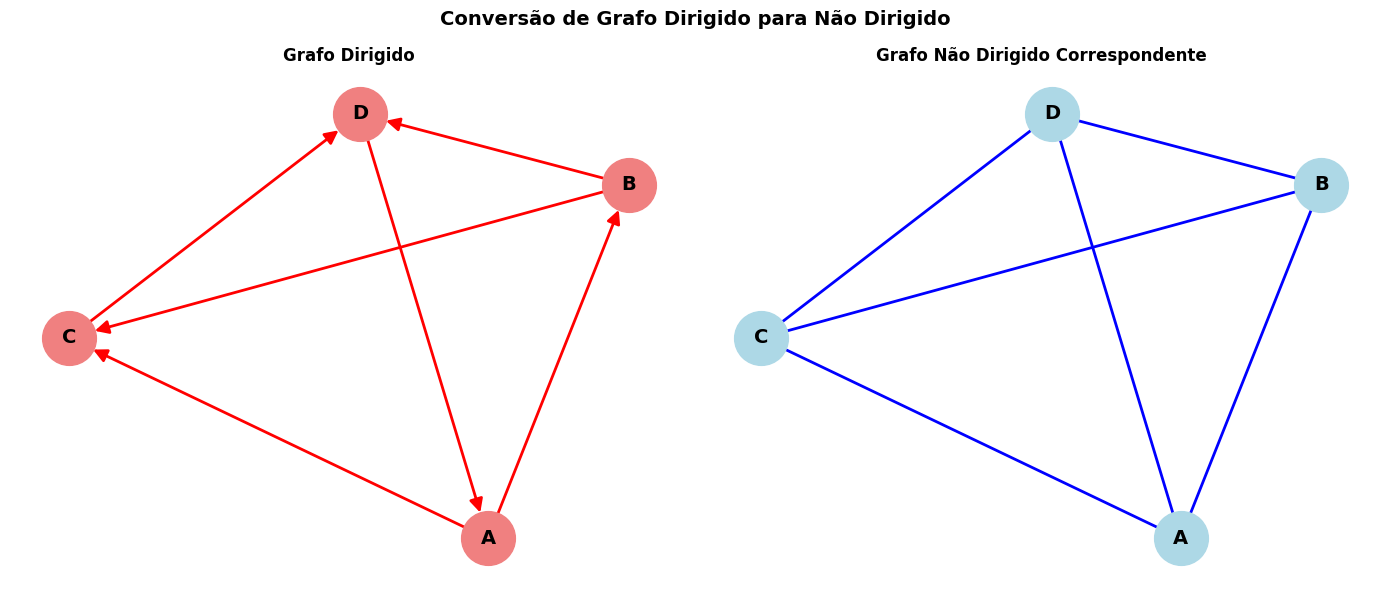

Para cada grafo dirigido, existe um grafo simples (não dirigido)
obtido removendo as direções das arestas.


In [5]:
# Comparação: Dirigido vs Não Dirigido
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# Grafo dirigido original
pos = nx.spring_layout(G_dirigido, seed=42)
nx.draw(G_dirigido, pos, ax=ax1,
        with_labels=True,
        node_color='lightcoral',
        node_size=1500,
        font_size=14,
        font_weight='bold',
        edge_color='red',
        width=2,
        arrows=True,
        arrowsize=20)
ax1.set_title('Grafo Dirigido', fontsize=12, fontweight='bold')
ax1.axis('off')

# Convertendo para não dirigido (removendo direções)
G_nao_dirigido = G_dirigido.to_undirected()
nx.draw(G_nao_dirigido, pos, ax=ax2,
        with_labels=True,
        node_color='lightblue',
        node_size=1500,
        font_size=14,
        font_weight='bold',
        edge_color='blue',
        width=2)
ax2.set_title('Grafo Não Dirigido Correspondente', fontsize=12, fontweight='bold')
ax2.axis('off')

plt.suptitle('Conversão de Grafo Dirigido para Não Dirigido', 
             fontsize=14, fontweight='bold', y=0.98)
plt.show()

print("Para cada grafo dirigido, existe um grafo simples (não dirigido)")
print("obtido removendo as direções das arestas.")

---

## 3. Grafo Completo ($K_n$)

### 📚 Definição:

Um **grafo completo** de $n$ vértices, denominado $K_n$, é um grafo simples com $n$ vértices onde o **conjunto de arestas contém exatamente uma aresta para cada par de vértices distintos**.

**Nota:** A letra $K$ representa a letra inicial da palavra alemã *komplett* ("completo").

### Número de Arestas em $K_n$:

$$|E| = \sum_{i=1}^{n-1} i = \frac{(n-1) \cdot n}{2} = \frac{n^2 - n}{2} = \frac{|V|^2 - |V|}{2} = \binom{n}{2}$$

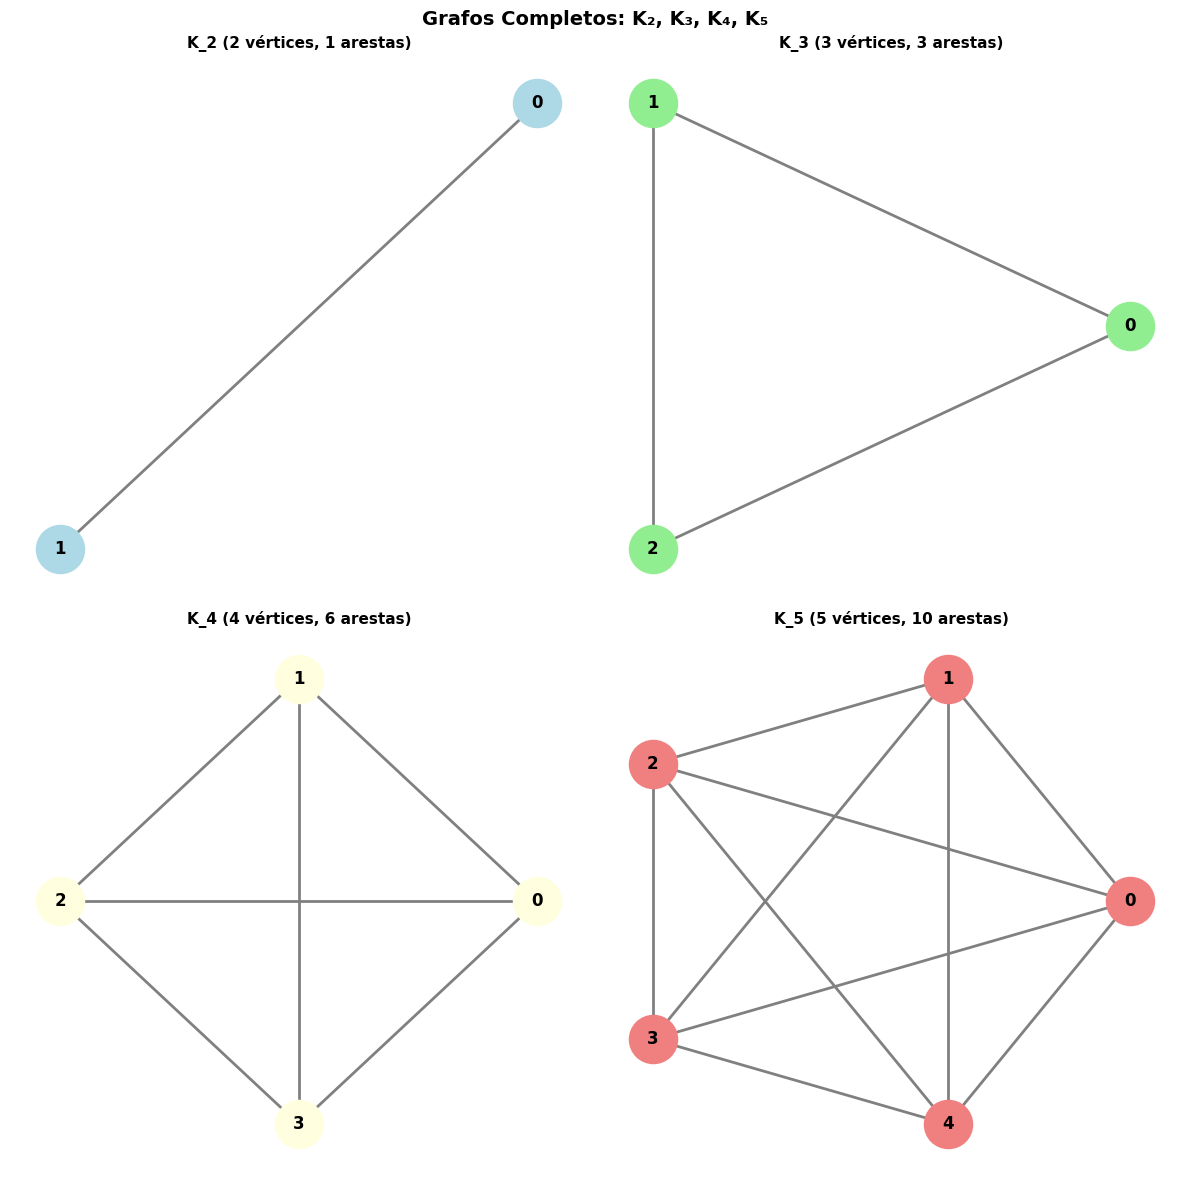

In [6]:
# Gerando grafos completos K2, K3, K4, K5
fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)
axes = axes.flatten()

cores = ['lightblue', 'lightgreen', 'lightyellow', 'lightcoral']

for i, n in enumerate([2, 3, 4, 5]):
    K_n = nx.complete_graph(n)
    num_arestas = K_n.number_of_edges()
    
    pos = nx.circular_layout(K_n)
    nx.draw(K_n, pos, ax=axes[i],
            with_labels=True,
            node_color=cores[i],
            node_size=1200,
            font_size=12,
            font_weight='bold',
            edge_color='gray',
            width=2)
    axes[i].set_title(f'K_{n} ({n} vértices, {num_arestas} arestas)', 
                     fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Grafos Completos: K₂, K₃, K₄, K₅', fontsize=14, fontweight='bold', y=0.98)
plt.show()

In [7]:
# Tabela: Quantidade de arestas
print("Tabela: Quantidade de Arestas em Grafos Completos")
print("=" * 40)
print(f"{'Grafo':<10} | {'# Vértices':<12} | {'# Arestas'}")
print("=" * 40)

for n in range(2, 11):
    num_arestas = (n * (n - 1)) // 2
    print(f"K_{n:<8} | {n:<12} | {num_arestas}")

print("\nFórmula: # arestas = n(n-1)/2 = C(n,2)")

Tabela: Quantidade de Arestas em Grafos Completos
Grafo      | # Vértices   | # Arestas
K_2        | 2            | 1
K_3        | 3            | 3
K_4        | 4            | 6
K_5        | 5            | 10
K_6        | 6            | 15
K_7        | 7            | 21
K_8        | 8            | 28
K_9        | 9            | 36
K_10       | 10           | 45

Fórmula: # arestas = n(n-1)/2 = C(n,2)


---

## 4. Grafo Ciclo ($C_n$)

### 📚 Definição:

Um **grafo ciclo** de $n$ vértices, denominado $C_n$ (onde $n \geq 3$), é um grafo simples com:
- $n$ vértices: $v_1, v_2, \ldots, v_n$
- Arestas: $v_1v_2, v_2v_3, \ldots, v_{n-1}v_n, v_nv_1$

Forma um **ciclo fechado**.

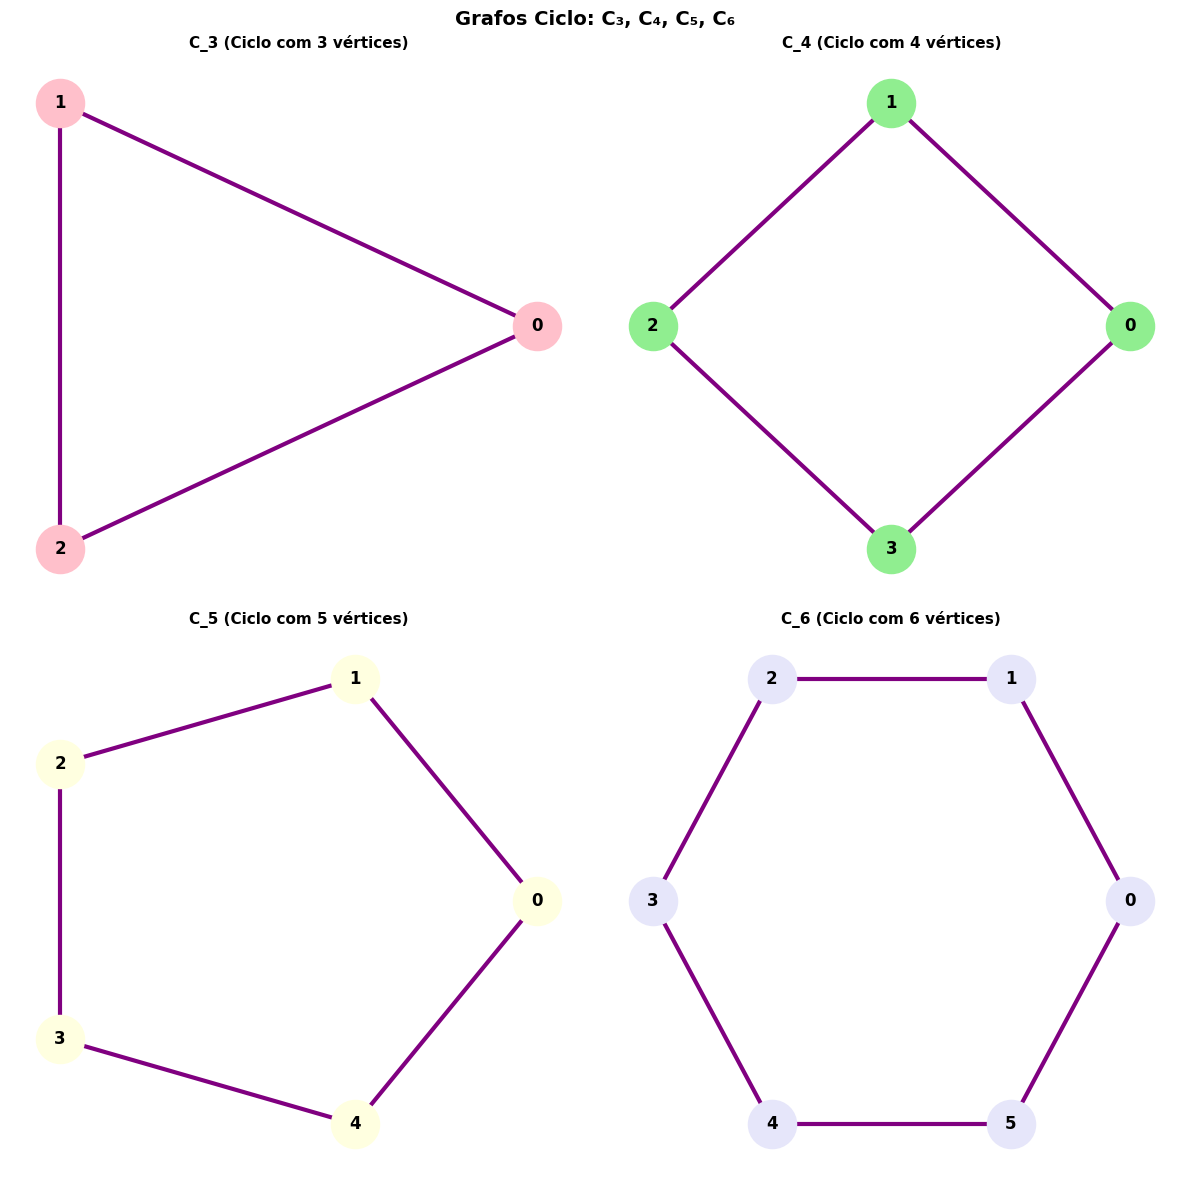

Características do Grafo Ciclo:
✓ Forma um ciclo fechado
✓ Cada vértice tem grau 2
✓ # arestas = # vértices


In [8]:
# Gerando grafos ciclo C3, C4, C5, C6
fig, axes = plt.subplots(2, 2, figsize=(12, 12), constrained_layout=True)
axes = axes.flatten()

cores = ['pink', 'lightgreen', 'lightyellow', 'lavender']

for i, n in enumerate([3, 4, 5, 6]):
    C_n = nx.cycle_graph(n)
    
    pos = nx.circular_layout(C_n)
    nx.draw(C_n, pos, ax=axes[i],
            with_labels=True,
            node_color=cores[i],
            node_size=1200,
            font_size=12,
            font_weight='bold',
            edge_color='purple',
            width=3)
    axes[i].set_title(f'C_{n} (Ciclo com {n} vértices)', 
                     fontsize=11, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Grafos Ciclo: C₃, C₄, C₅, C₆', fontsize=14, fontweight='bold', y=0.98)
plt.show()

print("Características do Grafo Ciclo:")
print(f"✓ Forma um ciclo fechado")
print(f"✓ Cada vértice tem grau 2")
print(f"✓ # arestas = # vértices")

---

## 5. Grafo Roda ($W_n$)

### 📚 Definição:

Um **grafo roda**, denominado $W_n$, é um grafo simples com $n+1$ vértices que é obtido:
1. Começando com um grafo ciclo $C_n$ (onde $n \geq 3$)
2. **Acrescentando um vértice central**
3. **Conectando este novo vértice a cada um dos $n$ vértices de $C_n$**

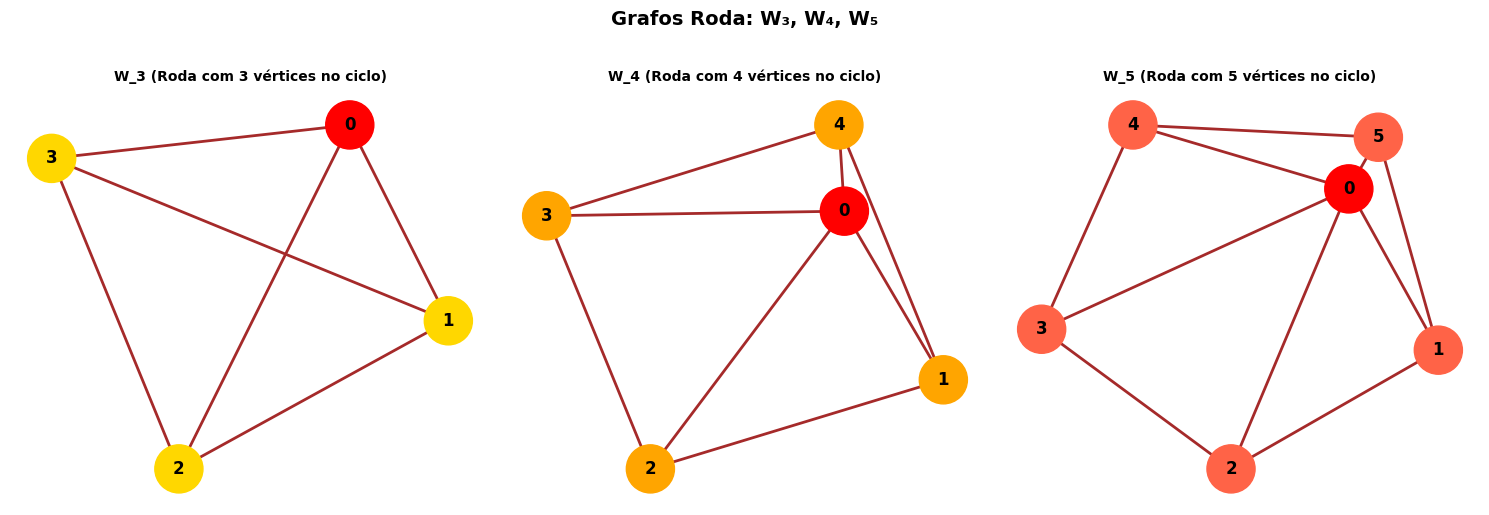

Características do Grafo Roda W_n:
✓ Tem n+1 vértices (n no ciclo + 1 central)
✓ Vértice central conectado a todos os outros
✓ # arestas = 2n (n do ciclo + n raios)


In [9]:
# Gerando grafos roda W3, W4, W5
fig, axes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)

cores = ['gold', 'orange', 'tomato']

for i, n in enumerate([3, 4, 5]):
    W_n = nx.wheel_graph(n + 1)  # n+1 porque o NetworkX conta o vértice central
    
    # Layout customizado para destacar o centro
    pos = nx.spring_layout(W_n, seed=42)
    # Forçar vértice 0 (central) no centro
    pos[0] = np.array([0.5, 0.5])
    
    # Cores diferentes para centro e borda
    node_colors = ['red' if node == 0 else cores[i] for node in W_n.nodes()]
    
    nx.draw(W_n, pos, ax=axes[i],
            with_labels=True,
            node_color=node_colors,
            node_size=1200,
            font_size=12,
            font_weight='bold',
            edge_color='brown',
            width=2)
    axes[i].set_title(f'W_{n} (Roda com {n} vértices no ciclo)', 
                     fontsize=10, fontweight='bold')
    axes[i].axis('off')

plt.suptitle('Grafos Roda: W₃, W₄, W₅', fontsize=14, fontweight='bold', y=1.02)
plt.show()

print("Características do Grafo Roda W_n:")
print(f"✓ Tem n+1 vértices (n no ciclo + 1 central)")
print(f"✓ Vértice central conectado a todos os outros")
print(f"✓ # arestas = 2n (n do ciclo + n raios)")

---

## 6. Comparação Visual dos Tipos de Grafos

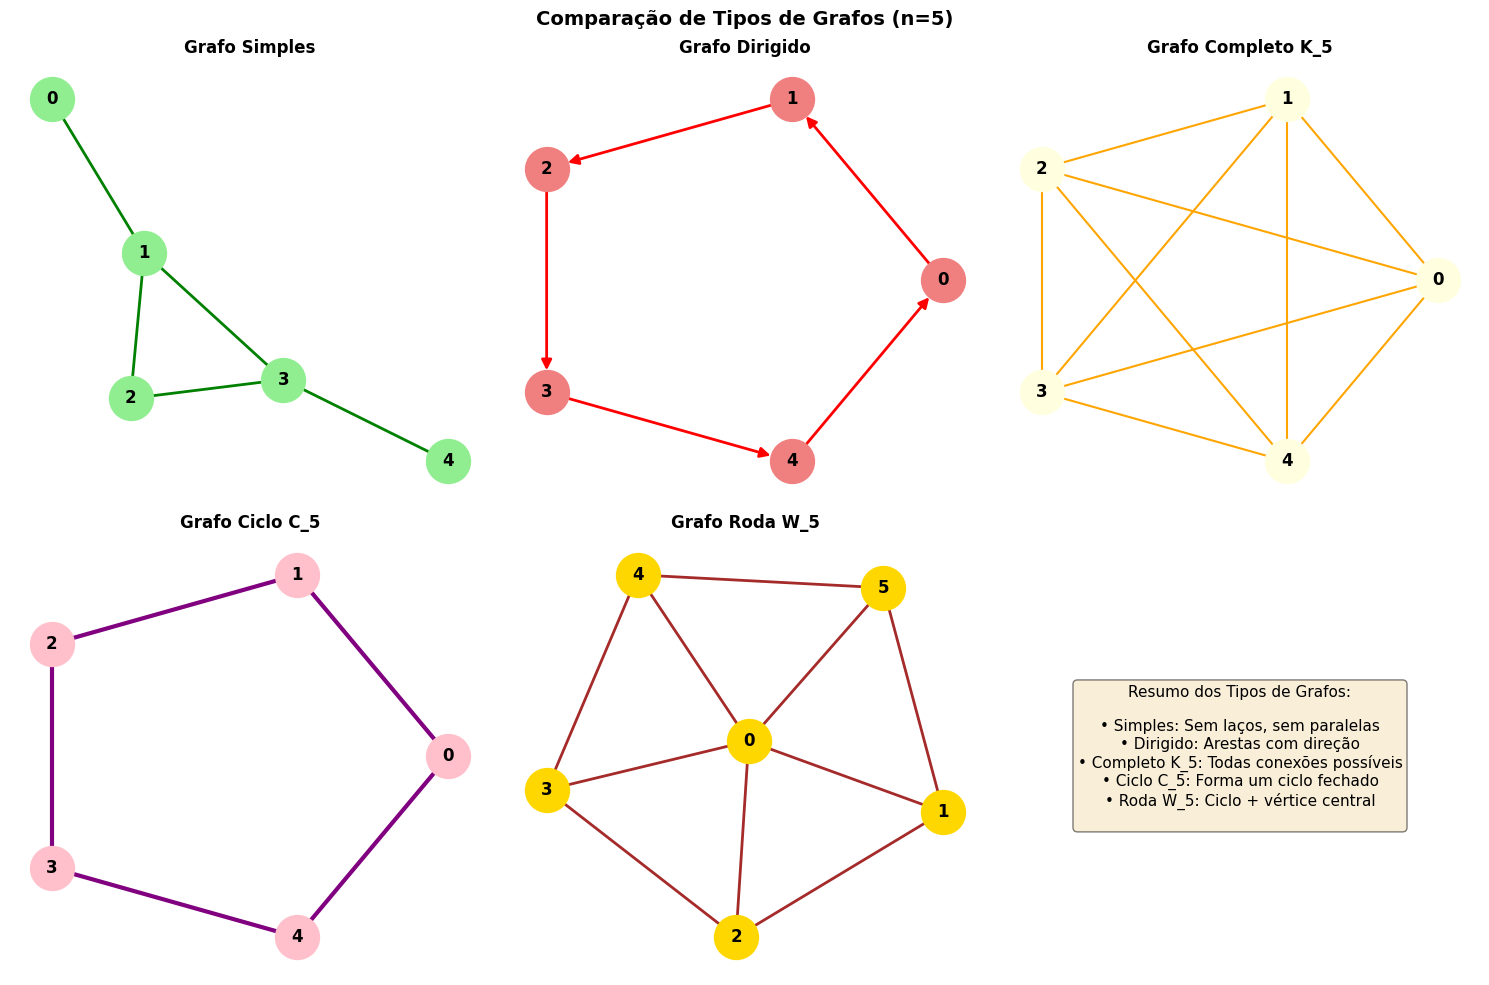

In [10]:
# Comparação de todos os tipos com 5 vértices
fig, axes = plt.subplots(2, 3, figsize=(15, 10), constrained_layout=True)
axes = axes.flatten()

n = 5

# 1. Grafo Simples
G_simp = nx.Graph()
G_simp.add_edges_from([(0,1), (1,2), (2,3), (3,4), (1,3)])
nx.draw(G_simp, nx.spring_layout(G_simp, seed=42, ax=ax), ax=axes[0],
        with_labels=True, node_color='lightgreen', node_size=1000,
        font_weight='bold', edge_color='green', width=2)
axes[0].set_title('Grafo Simples', fontweight='bold')
axes[0].axis('off')

# 2. Grafo Dirigido
G_dir = nx.DiGraph()
G_dir.add_edges_from([(0,1), (1,2), (2,3), (3,4), (4,0)])
nx.draw(G_dir, nx.circular_layout(G_dir, ax=ax), ax=axes[1],
        with_labels=True, node_color='lightcoral', node_size=1000,
        font_weight='bold', edge_color='red', width=2, arrows=True, arrowsize=15)
axes[1].set_title('Grafo Dirigido', fontweight='bold')
axes[1].axis('off')

# 3. Grafo Completo K5
K5 = nx.complete_graph(n)
nx.draw(K5, nx.circular_layout(K5, ax=ax), ax=axes[2],
        with_labels=True, node_color='lightyellow', node_size=1000,
        font_weight='bold', edge_color='orange', width=1.5)
axes[2].set_title(f'Grafo Completo K_{n}', fontweight='bold')
axes[2].axis('off')

# 4. Grafo Ciclo C5
C5 = nx.cycle_graph(n)
nx.draw(C5, nx.circular_layout(C5, ax=ax), ax=axes[3],
        with_labels=True, node_color='pink', node_size=1000,
        font_weight='bold', edge_color='purple', width=3)
axes[3].set_title(f'Grafo Ciclo C_{n}', fontweight='bold')
axes[3].axis('off')

# 5. Grafo Roda W5
W5 = nx.wheel_graph(n + 1)
nx.draw(W5, nx.spring_layout(W5, seed=42, ax=ax), ax=axes[4],
        with_labels=True, node_color='gold', node_size=1000,
        font_weight='bold', edge_color='brown', width=2)
axes[4].set_title(f'Grafo Roda W_{n}', fontweight='bold')
axes[4].axis('off')

# 6. Legenda
axes[5].axis('off')
legenda_texto = (
    "Resumo dos Tipos de Grafos:\n\n"
    "• Simples: Sem laços, sem paralelas\n"
    "• Dirigido: Arestas com direção\n"
    f"• Completo K_{n}: Todas conexões possíveis\n"
    f"• Ciclo C_{n}: Forma um ciclo fechado\n"
    f"• Roda W_{n}: Ciclo + vértice central\n"
)
axes[5].text(0.5, 0.5, legenda_texto, 
            ha='center', va='center', fontsize=11,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.suptitle('Comparação de Tipos de Grafos (n=5)', fontsize=14, fontweight='bold', y=0.98)
plt.show()

---

## 7. Exercícios Práticos

In [11]:
# Exercício: Criar diferentes tipos de grafos
print("🎯 EXERCÍCIO: Complete o código para criar os grafos pedidos\n")

# TODO 1: Crie um grafo completo K6
K6 = nx.complete_graph(6)
print(f"✓ K6 criado: {K6.number_of_nodes()} vértices, {K6.number_of_edges()} arestas")

# TODO 2: Crie um grafo ciclo C7
C7 = nx.cycle_graph(7)
print(f"✓ C7 criado: {C7.number_of_nodes()} vértices, {C7.number_of_edges()} arestas")

# TODO 3: Crie um grafo roda W6
W6 = nx.wheel_graph(7)  # 7 porque inclui o centro
print(f"✓ W6 criado: {W6.number_of_nodes()} vértices, {W6.number_of_edges()} arestas")

# TODO 4: Verifique se um grafo é completo
def eh_completo(G):
    n = G.number_of_nodes()
    m = G.number_of_edges()
    return m == n * (n - 1) // 2

print(f"\n✓ K6 é completo? {eh_completo(K6)}")
print(f"✓ C7 é completo? {eh_completo(C7)}")
print(f"✓ W6 é completo? {eh_completo(W6)}")

🎯 EXERCÍCIO: Complete o código para criar os grafos pedidos

✓ K6 criado: 6 vértices, 15 arestas
✓ C7 criado: 7 vértices, 7 arestas
✓ W6 criado: 7 vértices, 12 arestas

✓ K6 é completo? True
✓ C7 é completo? False
✓ W6 é completo? False


---

## 📌 Resumo

Neste notebook, aprendemos sobre 5 tipos importantes de grafos:

| Tipo | Notação | Características |
|------|---------|----------------|
| **Simples** | $G$ | Sem laços, sem arestas paralelas |
| **Dirigido** | $G$ | Arestas com direção (setas) |
| **Completo** | $K_n$ | Todas as conexões possíveis: $\frac{n(n-1)}{2}$ arestas |
| **Ciclo** | $C_n$ | Forma ciclo fechado, $n$ arestas |
| **Roda** | $W_n$ | Ciclo + vértice central, $2n$ arestas |

### 🎯 Próximo notebook:
**04_grafos_especiais.ipynb** - Grafos bipartidos, multigrafos, hipergrafos, grafos valorados e planares